In [21]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [22]:
import src.loader.load as load_module
reload(load_module)
load_data = load_module.load_data

data = load_data(r"./dummy_cell_tracks.csv", {'id': 'track_id', 'x': 'x_coordinate', 'y': 'y_coordinate', 't': 'time_point'}, spatial_unit="micrometer", time_unit="second")

import src.compute.stats as stats_module
reload(stats_module)
stats = stats_module.stats

spots = stats.spots(data)
spots

track_id,time_point,x_coordinate,y_coordinate,set,track_uid,frame,distance,cum_track_length,cum_track_displacement,cum_straightness_ratio,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
f64,f64,f64,f64,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,25.0,242.8987,57.809882,"""dummy_cell_tracks.csv""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1.0,26.0,245.228029,54.597547,"""dummy_cell_tracks.csv""",0,1,3.96798,3.96798,3.96798,1.0,3.96798,1.98399,0.5,-0.943409,null,null,null,null,-0.943409,0.0
1.0,27.0,249.827267,49.532794,"""dummy_cell_tracks.csv""",0,2,6.841398,10.809378,10.794222,0.998598,5.404689,3.598074,0.665732,-0.833531,6.295573,6.295573,6.295573,2.098524,-0.88847,0.001509
1.0,28.0,252.715365,45.316116,"""dummy_cell_tracks.csv""",0,3,5.110918,15.920296,15.889025,0.998036,5.306765,3.972256,0.748527,-0.970261,7.834063,14.129636,7.064818,1.766204,-0.915755,0.001749
1.0,29.0,253.585434,39.076147,"""dummy_cell_tracks.csv""",0,4,6.300336,22.220632,21.567548,0.970609,5.555158,4.31351,0.776487,-1.432255,26.470285,40.59992,13.533307,2.706661,-1.042861,0.026066
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
24.0,95.0,165.663738,651.145494,"""dummy_cell_tracks.csv""",23,73,6.204479,466.606803,433.355841,0.928739,6.391874,5.85616,0.916188,2.571644,18.846007,675.379179,9.380266,0.12676,1.639609,0.072347
24.0,96.0,160.947074,653.762386,"""dummy_cell_tracks.csv""",23,74,5.393981,472.000784,436.290539,0.924343,6.378389,5.817207,0.912018,2.635058,3.633354,679.012533,9.301542,0.124021,1.651899,0.07746
24.0,97.0,151.214694,656.336399,"""dummy_cell_tracks.csv""",23,75,10.067014,482.067798,439.679452,0.91207,6.427571,5.785256,0.900069,2.883033,14.207968,693.2205,9.367845,0.123261,1.665642,0.085232


In [24]:
tracks = stats.tracks(spots)
tracks

set,track_uid,speed_min,speed_max,speed_mean,speed_sd,speed_median,track_length,x_location,y_location,max_distance_reached,track_start_frame,track_end_frame,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_points,track_displacement,straightness_ratio,track_id
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""dummy_cell_tracks.csv""",0,1.887846,7.510075,5.082366,1.269828,5.083618,304.941987,283.778506,45.61418,98.017388,0,60,0.740143,0.14563,1.989782,0.872256,22.933125,0.375953,61,45.148695,0.148057,1.0
"""dummy_cell_tracks.csv""",1,0.630499,4.222559,2.283464,0.703156,2.40081,159.842451,240.840282,445.548959,95.156701,0,70,1.07369,0.470203,0.364791,0.507672,25.993921,0.366112,71,76.232016,0.47692,2.0
"""dummy_cell_tracks.csv""",2,1.759553,6.590044,4.393083,1.142602,4.50847,224.04724,457.707324,315.750483,94.385655,0,51,1.815109,0.413174,-2.706101,0.639079,31.518122,0.606118,52,94.385655,0.421276,3.0
"""dummy_cell_tracks.csv""",3,0.450875,3.833588,2.179035,0.72064,2.158041,167.785657,62.259575,379.690134,87.623116,0,77,0.860449,0.394876,0.566807,0.60872,27.588468,0.353698,78,67.115054,0.400005,4.0
"""dummy_cell_tracks.csv""",4,0.43936,3.481555,2.097215,0.607012,2.142603,199.235398,26.383808,163.980298,65.688448,0,95,0.636257,0.303382,1.520506,0.706146,44.33701,0.461844,96,61.080718,0.306576,5.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""dummy_cell_tracks.csv""",19,1.816875,5.021864,3.582072,0.781827,3.563065,232.834664,171.07882,375.607525,154.795077,0,65,2.34538,0.654755,0.521693,0.322555,28.332762,0.429284,66,154.795077,0.664828,20.0
"""dummy_cell_tracks.csv""",20,2.494322,7.844056,5.012304,1.111571,4.846977,260.639782,458.273866,300.549011,77.337167,0,52,1.427528,0.284805,-2.614556,0.710084,31.6436,0.597049,53,75.658984,0.290282,21.0
"""dummy_cell_tracks.csv""",21,3.623673,11.663155,7.587504,1.495519,7.499053,644.937856,86.925687,147.189939,242.3818,0,85,1.132674,0.149282,-2.667513,0.870917,20.804783,0.241916,86,97.410005,0.151038,22.0



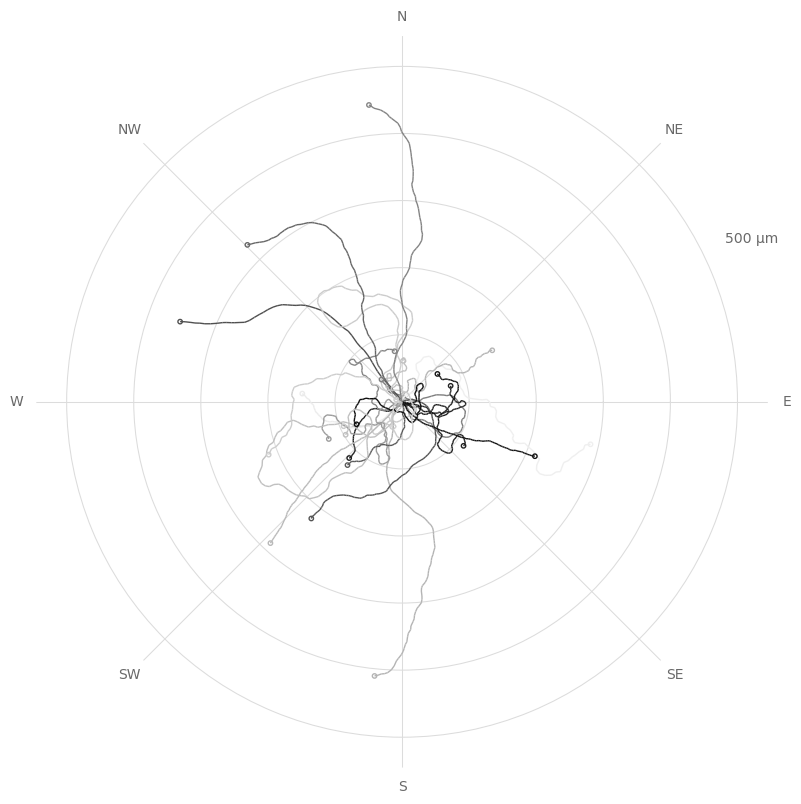

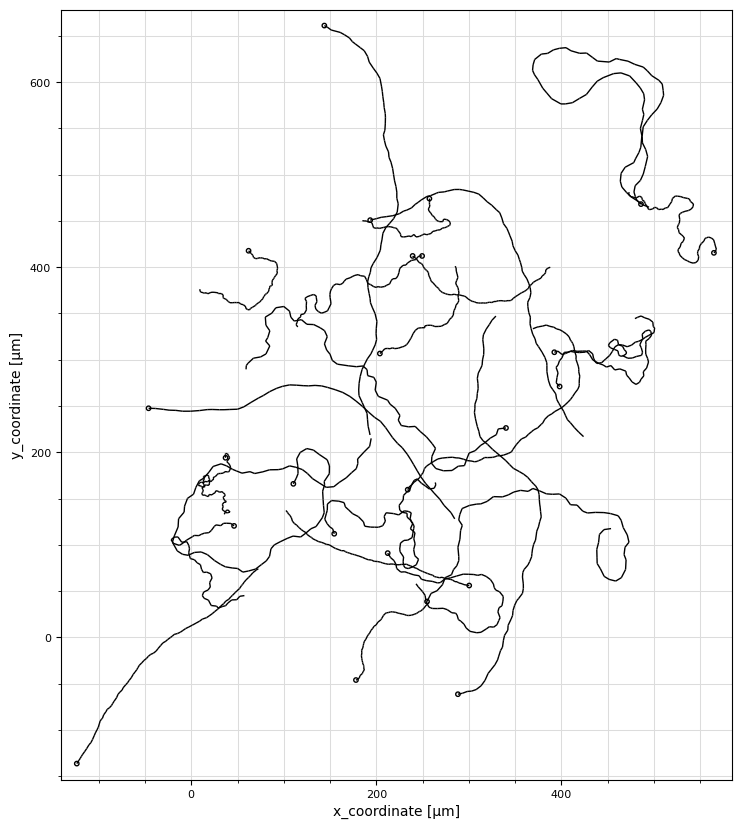

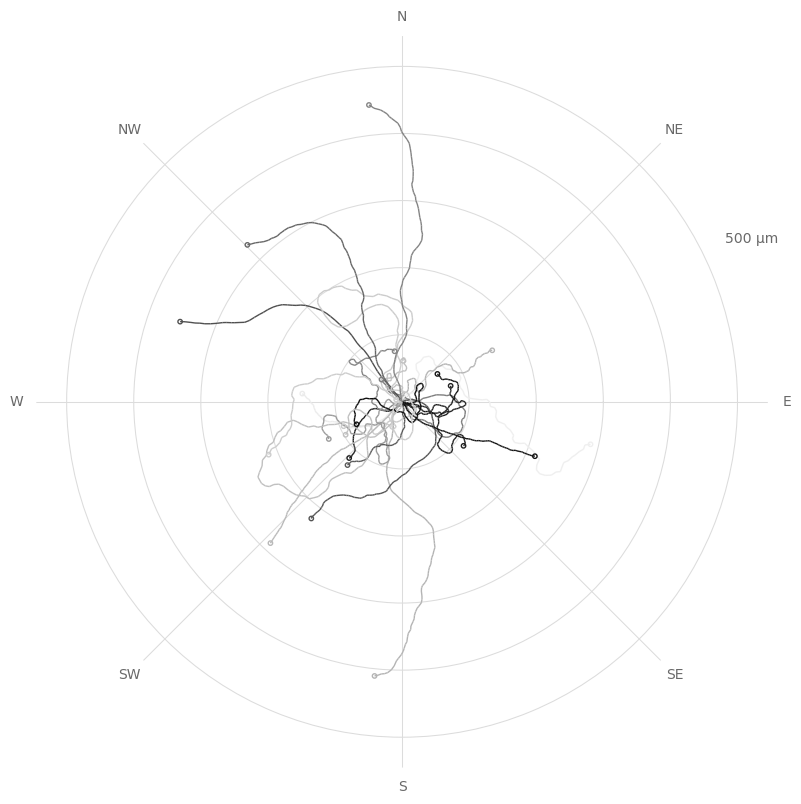

In [ ]:
import src.plot.painter as painter_module
reload(painter_module)

import src.plot.tracks.reconstruct as reconstruct_module
reload(reconstruct_module)
reconstruct = reconstruct_module.reconstruct

reconstruct(spots)
reconstruct(spots, color='random greys', align_at_start=True)

C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\plot\painter.py:288: ConflictingParametersWarning: Both 'color' and 'color_by' parameters are provided -> Parameter 'color' will be ignored -> Using 'color_by' for color assignment.
  return False



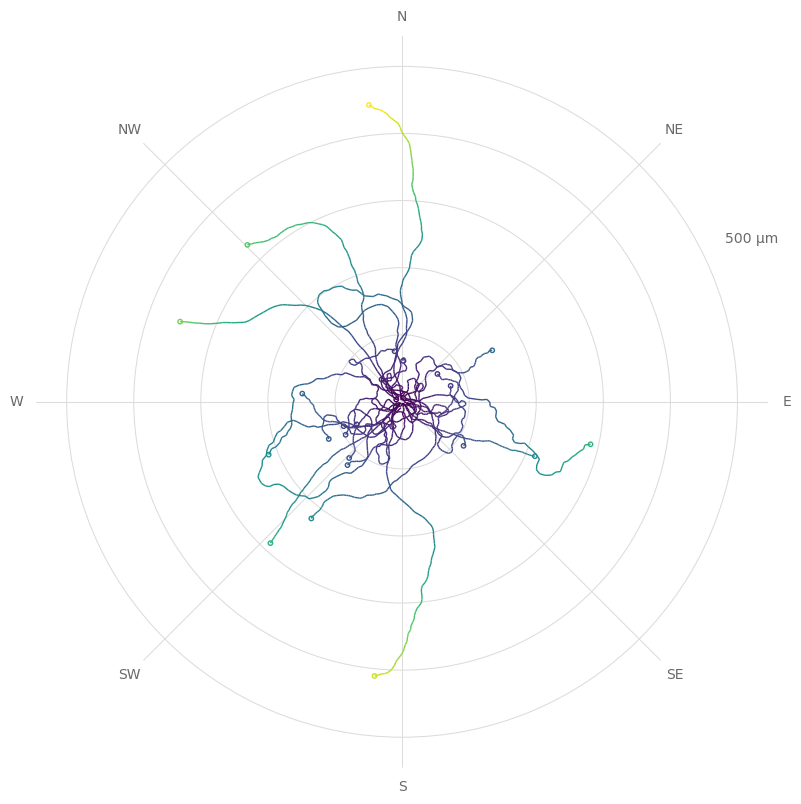

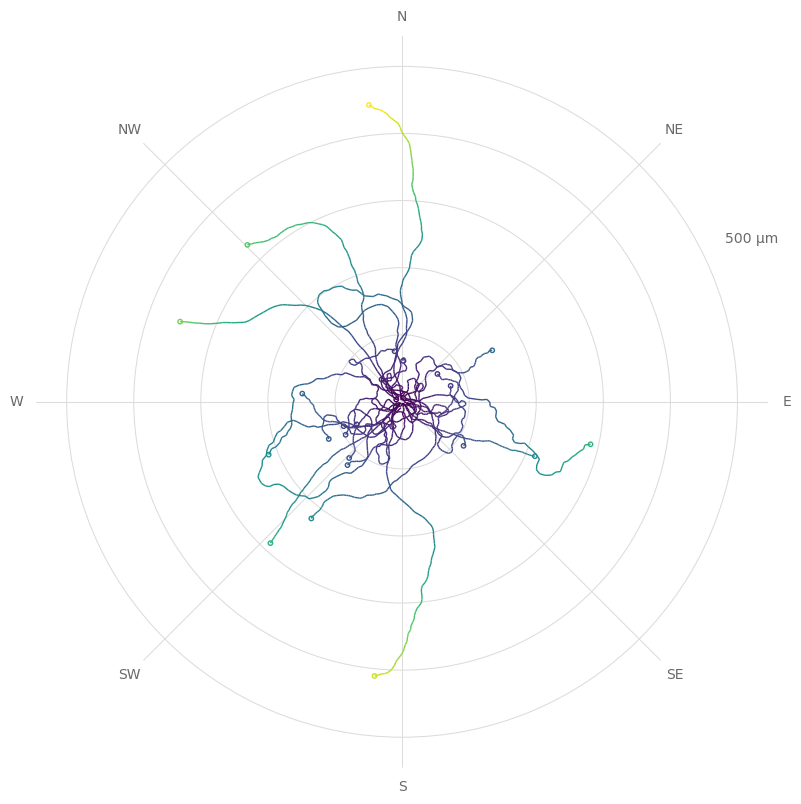

In [28]:
reconstruct(spots, tracks, color_by='cum_track_displacement', align_at_start=True)